In [1]:
"""
Unit 5: Evolving Your IPD Agent with Genetic Algorithms
========================================================

In Unit 4, you hand-coded agent strategies like Tit-for-Tat.
In Unit 5, you'll use evolution to DISCOVER strategies automatically.

By the end, you'll have an evolved agent saved as a JSON file for the tournament!
"""

# ============================================================================
# SETUP: Import everything from previous units
# ============================================================================

import random
import numpy as np
import json
import matplotlib.pyplot as plt
from agents import Agent, INVEST, UNDERCUT
from game_engine import Game, Tournament

# Import all hand-coded agents from Unit 4
from agents import (
    AlwaysInvestAgent, AlwaysUndercutAgent, TitForTatAgent,
    GrimTriggerAgent, PavlovAgent, TitForTwoTatsAgent,
    GenerousTitForTatAgent, AdaptiveAgent, RandomAgent,
    SuspiciousTitForTatAgent, GradualAgent, HardMajorityAgent,
    SoftMajorityAgent, ProberAgent
)

print("✅ Imports complete!")

✅ Imports complete!


In [3]:

# ============================================================================
# PART 1: THE EVOLVABLE AGENT (PROVIDED - Read but don't modify)
# ============================================================================

class EvolvableAgent(Agent):
    """
    An agent whose strategy is controlled by 6 genes (numbers from 0 to 1).
    
    Think of genes as "strategy dials" you can tune:
    
    Gene[0] - Initial Cooperation (0=hostile start, 1=friendly start)
    Gene[1] - Cooperation Response (if opponent cooperates, how likely to cooperate back?)
    Gene[2] - Defection Response (if opponent defects, how likely to defect back?)
    Gene[3] - Forgiveness (after retaliation, chance to forgive)
    Gene[4] - Memory Length (0=last 1 round, 1=last 10 rounds)
    Gene[5] - Retaliation Threshold (what % of defections triggers retaliation)
    """
    
    def __init__(self, genes=None, name="Evolved Agent"):
        if genes is None:
            # Create random genes if none provided
            genes = [random.random() for _ in range(6)]
        
        self.genes = genes
        super().__init__(name, f"Genes: [{', '.join([f'{g:.2f}' for g in genes])}]")
    
    def choose_action(self) -> bool:
        """Decision logic based on genes - SIMPLIFIED FOR LEARNING"""
        
        # First 3 rounds: use initial cooperation gene
        if self.round_num < 3:
            return random.random() < self.genes[0]
        
        # Calculate memory window (gene[4])
        memory_length = max(1, int(self.genes[4] * 10) + 1)
        recent_history = self.history[-memory_length:]
        
        # Calculate opponent's recent COOPERATION rate (not defection!)
        cooperation_rate = sum(recent_history) / len(recent_history)
        
        # If opponent is mostly cooperating, reciprocate
        if cooperation_rate >= 0.5:
            return random.random() < self.genes[1]  # gene[1] = cooperate response
        
        # If opponent is mostly defecting, retaliate or forgive
        else:
            # Retaliate with probability gene[2]
            if random.random() < self.genes[2]:
                return UNDERCUT
            # Or forgive with probability gene[3]
            elif random.random() < self.genes[3]:
                return INVEST
            else:
                return UNDERCUT


In [8]:

# ============================================================================
# PART 2: DEFINE THE OPPONENT ECOSYSTEM
# ============================================================================

# ============================================================================
# EXPANDED OPPONENT POOL
# ============================================================================

# Full pool of all possible opponents
full_opponent_pool = [
    # Cooperative agents
    AlwaysInvestAgent(),
    TitForTatAgent(),
    GrimTriggerAgent(),
    PavlovAgent(),
    TitForTwoTatsAgent(),
    GenerousTitForTatAgent(),
    AdaptiveAgent(),
    
    # Aggressive agents
    AlwaysUndercutAgent(),
    SuspiciousTitForTatAgent(),
    
    # Sophisticated agents
    GradualAgent(),
    ProberAgent(),
    
    # Majority-based agents
    HardMajorityAgent(),
    SoftMajorityAgent(),
    
    # Random agents with different cooperation levels
    RandomAgent(0.9),
    RandomAgent(0.7),
    RandomAgent(0.5),
    RandomAgent(0.3),
    RandomAgent(0.1),
]

print(f"\n📚 Full opponent library: {len(full_opponent_pool)} agents available")

# For initial evolution, randomly sample opponents
opponent_pool = random.sample(full_opponent_pool, 10)

print(f"🎲 Randomly selected {len(opponent_pool)} opponents for this evolution:")
for i, opp in enumerate(opponent_pool, 1):
    print(f"  {i:2d}. {opp.name:25s} - {opp.description}")
print("="*70)




📚 Full opponent library: 18 agents available
🎲 Randomly selected 10 opponents for this evolution:
   1. Random (0.7)              - Randomly invests 70% of the time
   2. Tit-for-Tat               - Starts friendly, then copies opponent
   3. Always Invest             - Always invests in market development
   4. Hard Majority             - Defects if opponent defects >50% of time
   5. Prober                    - Tests opponent's response, then adapts
   6. Suspicious Tit-for-Tat    - Starts hostile, then copies opponent
   7. Grim Trigger              - Invests until betrayed once, then undercuts forever
   8. Random (0.5)              - Randomly invests 50% of the time
   9. Soft Majority             - Cooperates if opponent cooperates >=50% of time
  10. Pavlov                    - Win-Stay-Lose-Shift strategy


In [9]:

# ============================================================================
# PART 3: GENETIC ALGORITHM FUNCTIONS (YOUR TODO!)
# ============================================================================

def initialize_population(pop_size):
    """
    Create initial population of random agents.
    
    Args:
        pop_size: Number of agents in population
    
    Returns:
        List of EvolvableAgent objects with random genes
    """
    population = []
    for i in range(pop_size):
        agent = EvolvableAgent(name=f"Agent_{i}")
        population.append(agent)
    return population


def evaluate_fitness(agent, opponents, num_rounds=50):
    """
    Measure how good an agent is by playing against all opponents.
    
    Args:
        agent: The EvolvableAgent to evaluate
        opponents: List of opponent agents to play against
        num_rounds: Number of rounds per game
    
    Returns:
        Float: Average score per game (higher is better)
    """
    total_score = 0
    num_games = 0
    
    for opponent in opponents:
        game = Game(agent, opponent, num_rounds=num_rounds)
        score, _ = game.play()
        total_score += score
        num_games += 1
    
    avg_score = total_score / num_games
    return avg_score


def tournament_selection(population, fitnesses, tournament_size=3):
    """
    Select parents using tournament selection.
    
    1. Pick tournament_size random individuals
    2. Choose the one with best fitness
    3. Repeat until we have pop_size selected parents
    """
    selected = []
    
    for _ in range(len(population)):
        # Pick random contestants
        contestants_idx = random.sample(range(len(population)), tournament_size)
        
        # Find the one with best fitness
        best_idx = max(contestants_idx, key=lambda i: fitnesses[i])
        
        # Add winner to selected (make a copy of genes)
        winner_genes = population[best_idx].genes.copy()
        selected.append(EvolvableAgent(genes=winner_genes))
    
    return selected


def crossover_and_mutate(parent1, parent2, mutation_rate=0.15):
    """
    Create a child from two parents using single-point crossover,
    then mutate each gene with probability mutation_rate
    (Gaussian noise, std=0.2, clipped to [0, 1]).
    """
    # Crossover
    crossover_point = random.randint(1, 5)
    child_genes = (parent1.genes[:crossover_point] + 
                   parent2.genes[crossover_point:])
    
    # Mutation
    for i in range(len(child_genes)):
        if random.random() < mutation_rate:
            child_genes[i] += random.gauss(0, 0.2)
            child_genes[i] = max(0.0, min(1.0, child_genes[i]))
    
    return EvolvableAgent(genes=child_genes)


def evolve(generations=25, pop_size=20, opponents=None, mutation_rate=0.15, elitism=2):
    """
    Run the genetic algorithm to evolve an agent.
    
    1. Create initial random population
    2. For each generation:
       a. Evaluate fitness of all agents
       b. Keep best agents (elitism)
       c. Select parents via tournament selection
       d. Create children via crossover & mutation
    3. Return the best agent found
    """
    if opponents is None:
        opponents = opponent_pool
    
    print(f"\n🧬 EVOLUTION STARTING")
    print(f"{'='*70}")
    print(f"Population: {pop_size} | Generations: {generations} | Mutation: {mutation_rate}")
    print(f"Opponents: {len(opponents)} | Elitism: {elitism}")
    print(f"{'='*70}\n")
    
    best_fitness_history = []
    avg_fitness_history = []
    
    population = initialize_population(pop_size)
    
    best_overall_agent = None
    best_overall_fitness = -float('inf')
    
    for gen in range(generations):
        # Evaluate fitness for all agents
        fitnesses = []
        for agent in population:
            fitness = evaluate_fitness(agent, opponents, num_rounds=50)
            fitnesses.append(fitness)
        
        # Track best and average
        best_fitness = max(fitnesses)
        avg_fitness = sum(fitnesses) / len(fitnesses)
        best_fitness_history.append(best_fitness)
        avg_fitness_history.append(avg_fitness)
        
        # Track best agent ever seen (copy the genes!)
        best_idx = fitnesses.index(best_fitness)
        if best_fitness > best_overall_fitness:
            best_overall_fitness = best_fitness
            best_overall_agent = EvolvableAgent(genes=population[best_idx].genes.copy())
        
        print(f"Gen {gen+1:3d}/{generations}: "
              f"Best={best_fitness:6.2f} | Avg={avg_fitness:6.2f} | "
              f"Genes={[f'{g:.2f}' for g in population[best_idx].genes]}")
        
        # Create next generation (unless this is the last generation)
        if gen < generations - 1:
            # Elitism: keep the top agents unchanged
            sorted_indices = sorted(range(len(fitnesses)), 
                                    key=lambda i: fitnesses[i], 
                                    reverse=True)
            next_population = []
            for i in range(elitism):
                elite_genes = population[sorted_indices[i]].genes.copy()
                next_population.append(EvolvableAgent(genes=elite_genes))
            
            # Selection
            selected = tournament_selection(population, fitnesses)
            
            # Fill the rest with children
            while len(next_population) < pop_size:
                parent1, parent2 = random.sample(selected, 2)
                child = crossover_and_mutate(parent1, parent2, mutation_rate)
                next_population.append(child)
            
            population = next_population
    
    print(f"\n{'='*70}")
    print(f"✅ EVOLUTION COMPLETE!")
    print(f"🏆 Best fitness achieved: {best_overall_fitness:.2f}")
    print(f"{'='*70}\n")
    
    # Plot evolution progress
    plt.figure(figsize=(10, 6))
    plt.plot(range(1, generations+1), best_fitness_history, 
             label='Best Fitness', linewidth=2, color='green', marker='o')
    plt.plot(range(1, generations+1), avg_fitness_history, 
             label='Average Fitness', linewidth=2, color='blue', marker='s', alpha=0.7)
    plt.xlabel('Generation', fontsize=12)
    plt.ylabel('Fitness (Avg Score per Game)', fontsize=12)
    plt.title('Evolution Progress', fontsize=14, fontweight='bold')
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    return best_overall_agent



🚀 TIME TO EVOLVE YOUR AGENT!

🧬 EVOLUTION STARTING
Population: 30 | Generations: 100 | Mutation: 0.1
Opponents: 10 | Elitism: 2

Gen   1/100: Best=128.60 | Avg=110.83 | Genes=['0.68', '0.50', '0.44', '0.49', '0.12', '0.02']
Gen   2/100: Best=128.30 | Avg=114.08 | Genes=['0.35', '0.69', '0.63', '0.44', '0.99', '0.01']
Gen   3/100: Best=133.30 | Avg=118.11 | Genes=['0.98', '0.49', '0.12', '0.97', '0.79', '0.83']
Gen   4/100: Best=136.50 | Avg=116.70 | Genes=['0.60', '0.50', '0.44', '0.97', '0.87', '0.63']
Gen   5/100: Best=133.20 | Avg=120.74 | Genes=['0.52', '0.50', '0.18', '0.97', '0.87', '0.63']
Gen   6/100: Best=132.80 | Avg=119.30 | Genes=['1.00', '0.49', '0.12', '0.59', '0.99', '0.12']
Gen   7/100: Best=132.70 | Avg=122.29 | Genes=['0.65', '0.69', '0.00', '0.22', '0.99', '0.12']
Gen   8/100: Best=135.40 | Avg=118.89 | Genes=['0.65', '0.69', '0.00', '0.22', '0.99', '0.12']
Gen   9/100: Best=130.40 | Avg=118.68 | Genes=['0.63', '0.69', '0.00', '0.22', '0.99', '0.12']
Gen  10/100: Be

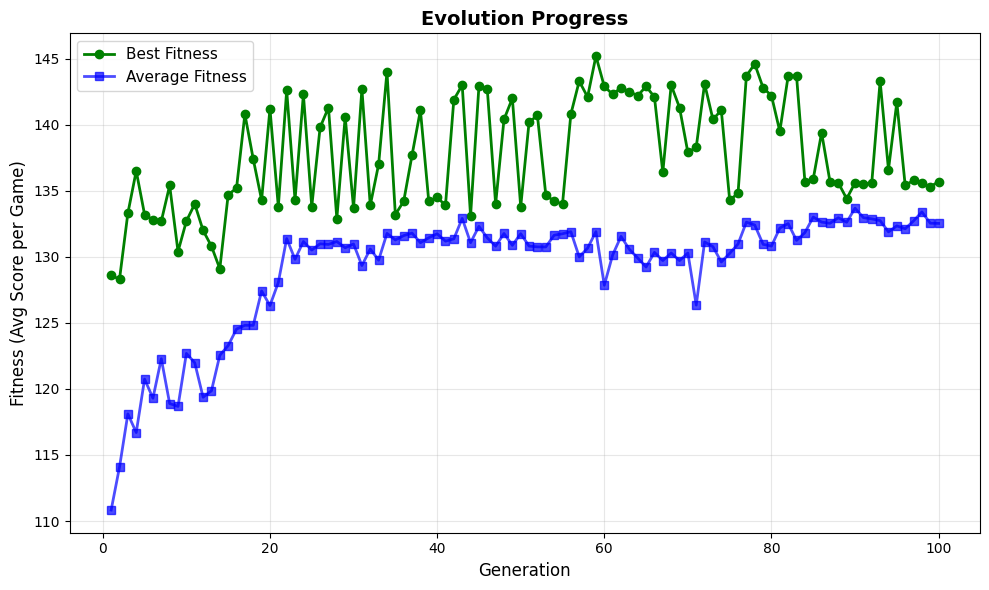


🎉 Your evolved agent's final genes:
   [0.8771981969341427, 1.0, 1.0, 0.1783153550041875, 0.6525771502441624, 0.1863273298144676]


In [10]:

# ============================================================================
# PART 4: RUN EVOLUTION! 
# ============================================================================

print("\n" + "="*70)
print("🚀 TIME TO EVOLVE YOUR AGENT!")
print("="*70)

# TODO: Experiment with these parameters to find the best agent!
my_evolved_agent = evolve(
    generations=100,       # Try: 50, 100, 250
    pop_size=30,         # Try: 15, 20, 30
    opponents=opponent_pool,
    mutation_rate=0.1,  # Try: 0.1, 0.15, 0.2
    elitism=2            # Keep top 2 agents each generation
)

print(f"\n🎉 Your evolved agent's final genes:")
print(f"   {my_evolved_agent.genes}")



In [11]:

# ============================================================================
# PART 5: TEST YOUR AGENT
# ============================================================================

print("\n" + "="*70)
print("⚔️  TESTING YOUR AGENT AGAINST HAND-CODED OPPONENTS")
print("="*70 + "\n")

wins = 0
losses = 0
ties = 0

for opponent in opponent_pool:
    game = Game(my_evolved_agent, opponent, num_rounds=100)
    my_score, opp_score = game.play()
    
    if my_score > opp_score:
        result = "✅ WON"
        wins += 1
    elif my_score < opp_score:
        result = "❌ LOST"
        losses += 1
    else:
        result = "🤝 TIED"
        ties += 1
    
    print(f"vs {opponent.name:25s}: {my_score:3d} - {opp_score:3d}  {result}")

print(f"\n📊 Record: {wins} wins, {losses} losses, {ties} ties")
win_rate = wins / len(opponent_pool) * 100
print(f"🎯 Win Rate: {win_rate:.1f}%")




⚔️  TESTING YOUR AGENT AGAINST HAND-CODED OPPONENTS

vs Random (0.7)             : 229 - 309  ❌ LOST
vs Tit-for-Tat              : 299 - 299  🤝 TIED
vs Always Invest            : 300 - 300  🤝 TIED
vs Hard Majority            : 300 - 300  🤝 TIED
vs Prober                   : 101 - 116  ❌ LOST
vs Suspicious Tit-for-Tat   : 292 - 297  ❌ LOST
vs Grim Trigger             : 104 - 109  ❌ LOST
vs Random (0.5)             : 228 - 178  ✅ WON
vs Soft Majority            : 302 - 297  ✅ WON
vs Pavlov                   : 300 - 300  🤝 TIED

📊 Record: 2 wins, 4 losses, 4 ties
🎯 Win Rate: 20.0%


# Unit 5 Part 2: Benchmark Analysis

**After running your initial evolution and benchmark tests, answer these questions.**

---

## Performance Summary

Fill in your benchmark results:

| Opponent | Result (W/L/T) | Your Score | Opp Score |
|----------|----------------|------------|-----------|
| Always Invest | T | 300 | 300 |
| Always Undercut | Not played | – | – |
| Tit-for-Tat | T | 299 | 299 |
| Grim Trigger | L | 104 | 109 |
| Pavlov | T | 300 | 300 |
| Tit-for-Two-Tats | Not played | – | – |
| Generous Tit-for-Tat | Not played | – | – |
| Adaptive | Not played | – | – |
| Random (0.7) | L | 229 | 309 |
| Random (0.3) | Not played | – | – |
| Hard Majority | T | 300 | 300 |
| Prober | L | 101 | 116 |
| Suspicious Tit-for-Tat | L | 292 | 297 |
| Random (0.5) | W | 228 | 178 |
| Soft Majority | W | 302 | 297 |
| **Total** | 2 W / 4 L / 4 T | 2455 | 2505 |

---

## Analysis Questions

### 1. What was your agent's worst loss (greatest point differential) and why?

My worst loss was against Random (0.7), 229 to 309. My agent was pretty cooperative so it kept investing even when the random agent undercut it. While the random agent still cooperated most of the time, my agent didn't really do as well. So it just kept getting taken advantage of.

---

### 2. What pattern do you see in wins vs. losses?

It tied with nice agents like Tit-for-Tat, Always Invest, and Pavlov because both just cooperated the whole game. It lost to agents that defect first or punish hard, like Prober, Grim Trigger, and Suspicious Tit-for-Tat. It only won against Random (0.5) and Soft Majority, and still not by much.

---

### 3. What would make an agent more competitive?

Always cooperate on the first move instead of being random for the first 3 rounds, so it doesn't trigger Grim Trigger. React to what the opponent did last round like Tit-for-Tat so it punishes defections right away. Also forgive sometimes so it doesn't get stuck in defect loops.

---

**Next:** Proceed to Part 3 to implement your improvements!

In [22]:

# ============================================================================
# PART 6: IMPROVE YOUR AGENT'S ACTION TAKING STRATEGY
# ============================================================================

class ImprovedEvolvableAgent(Agent):
    """
    IMPROVED agent with better gene encoding
    
    Students can modify:
    - Number of genes (currently 6, could add more)
    - What genes control
    - Decision logic (how genes map to actions)
    """
    
    def __init__(self, genes=None, name="Improved Agent"):
        if genes is None:
            genes = [random.random() for _ in range(6)]
        
        self.genes = genes
        super().__init__(name, f"Genes: [{', '.join([f'{g:.2f}' for g in genes])}]")
    
    def choose_action(self) -> bool:
        if self.round_num == 0 or len(self.history) == 0:
            return INVEST if self.genes[0] > 0.5 else UNDERCUT
        
        memory_length = max(1, int(self.genes[4] * 10) + 1)
        recent_history = self.history[-memory_length:]
        cooperation_rate = sum(recent_history) / len(recent_history)
        
        if len(self.history) >= 5 and cooperation_rate < self.genes[5] * 0.5:
            return UNDERCUT
        
        opp_last = self.history[-1]
        
        if opp_last == INVEST:
            loyalty = 0.85 + 0.15 * self.genes[1]
            return INVEST if random.random() < loyalty else UNDERCUT
        
        defected_twice = len(self.history) >= 2 and self.history[-2] == UNDERCUT
        
        if defected_twice or random.random() < self.genes[2]:
            if random.random() < self.genes[3] * 0.3:
                return INVEST
            return UNDERCUT
        
        return INVEST
    
    def save_to_file(self, filename):
        """Save agent to JSON"""
        data = {
            'name': self.name,
            'genes': self.genes,
            'description': self.description
        }
        with open(filename, 'w') as f:
            json.dump(data, f, indent=2)
        print(f"✅ Agent saved to {filename}")


🔧 EVOLVING YOUR IMPROVED AGENT!

🧬 EVOLUTION STARTING (Improved Agent)
Population: 100 | Generations: 30 | Mutation: 0.1
Opponents: 10 | Elitism: 2

Gen   1/30: Best=141.50 | Avg=120.75 | Genes=['0.66', '0.99', '0.49', '0.91', '0.44', '0.65']
Gen   2/30: Best=144.20 | Avg=124.64 | Genes=['0.71', '0.92', '0.37', '0.30', '0.63', '0.98']
Gen   3/30: Best=144.20 | Avg=127.60 | Genes=['0.58', '0.35', '0.95', '0.47', '1.00', '0.84']
Gen   4/30: Best=144.20 | Avg=128.78 | Genes=['0.61', '0.84', '0.75', '0.75', '0.79', '0.98']
Gen   5/30: Best=144.20 | Avg=131.76 | Genes=['0.87', '0.94', '0.90', '0.45', '0.19', '0.80']
Gen   6/30: Best=144.30 | Avg=132.45 | Genes=['1.00', '0.92', '0.90', '0.57', '0.64', '0.84']
Gen   7/30: Best=144.30 | Avg=134.34 | Genes=['0.65', '0.87', '0.37', '0.47', '0.46', '0.82']
Gen   8/30: Best=145.20 | Avg=135.74 | Genes=['1.00', '0.94', '0.85', '0.07', '0.79', '0.98']
Gen   9/30: Best=145.50 | Avg=135.69 | Genes=['0.92', '1.00', '0.70', '0.13', '0.63', '0.92']
Gen 

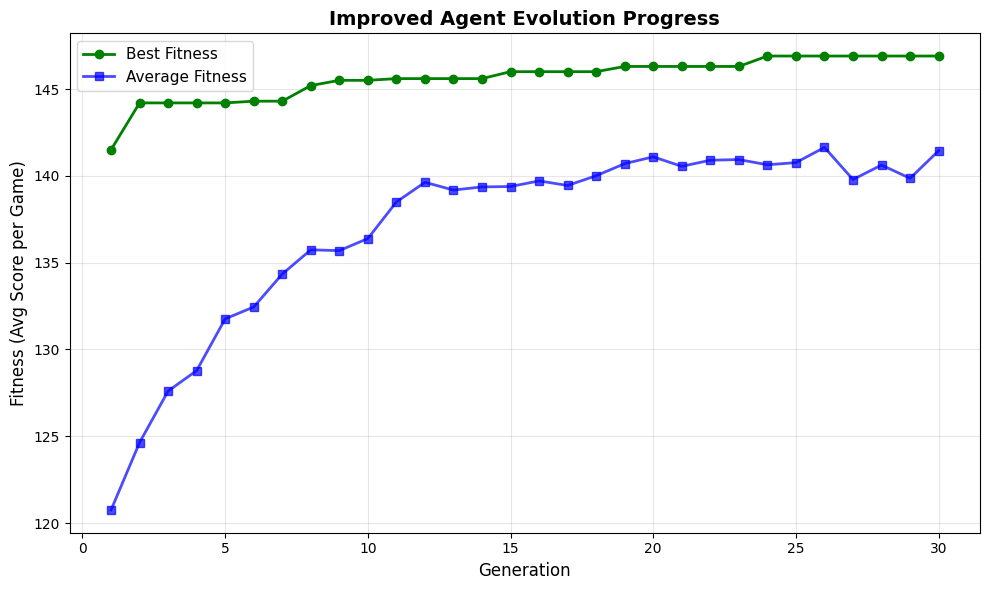


🎉 Your improved agent's final genes:
   [0.8014849888207329, 1.0, 0.9785192339640734, 0.4728080550680513, 0.47832914147859534, 0.8743497161749513]


In [28]:
# ============================================================================
# PART 7: EVOLVE YOUR IMPROVED AGENT
# ============================================================================


print("\n" + "="*70)
print("🔧 EVOLVING YOUR IMPROVED AGENT!")
print("="*70)


def evolve_improved(generations=25, pop_size=20, opponents=None, mutation_rate=0.15, elitism=2):
    """
    Evolve using the ImprovedEvolvableAgent class
    (Same as evolve() but uses ImprovedEvolvableAgent instead of EvolvableAgent)
    """
    if opponents is None:
        opponents = opponent_pool
    
    print(f"\n🧬 EVOLUTION STARTING (Improved Agent)")
    print(f"{'='*70}")
    print(f"Population: {pop_size} | Generations: {generations} | Mutation: {mutation_rate}")
    print(f"Opponents: {len(opponents)} | Elitism: {elitism}")
    print(f"{'='*70}\n")
    
    best_fitness_history = []
    avg_fitness_history = []
    
    # Initialize population with ImprovedEvolvableAgent
    population = [ImprovedEvolvableAgent(name=f"Agent_{i}") for i in range(pop_size)]
    
    best_overall_agent = None
    best_overall_fitness = -float('inf')
    
    for gen in range(generations):
        # Evaluate fitness
        fitnesses = []
        for agent in population:
            fitness = evaluate_fitness(agent, opponents, num_rounds=50)
            fitnesses.append(fitness)
        
        # Track best
        best_fitness = max(fitnesses)
        avg_fitness = sum(fitnesses) / len(fitnesses)
        
        # Update best overall
        best_idx = fitnesses.index(best_fitness)
        if best_fitness > best_overall_fitness:
            best_overall_fitness = best_fitness
            best_overall_agent = ImprovedEvolvableAgent(genes=population[best_idx].genes.copy())
        
        best_fitness_history.append(best_overall_fitness)
        avg_fitness_history.append(avg_fitness)
        
        print(f"Gen {gen+1:3d}/{generations}: "
              f"Best={best_overall_fitness:6.2f} | Avg={avg_fitness:6.2f} | "
              f"Genes={[f'{g:.2f}' for g in population[best_idx].genes]}")
        
        # Create next generation
        if gen < generations - 1:
            sorted_indices = sorted(range(len(fitnesses)), 
                                  key=lambda i: fitnesses[i], 
                                  reverse=True)
            
            # Elitism
            next_population = []
            for i in range(elitism):
                elite_genes = population[sorted_indices[i]].genes.copy()
                next_population.append(ImprovedEvolvableAgent(genes=elite_genes))
            
            # Selection
            selected = tournament_selection(population, fitnesses)
            
            # Crossover and mutation
            while len(next_population) < pop_size:
                parent1, parent2 = random.sample(selected, 2)
                child = crossover_and_mutate(parent1, parent2, mutation_rate)
                # Convert to ImprovedEvolvableAgent
                next_population.append(ImprovedEvolvableAgent(genes=child.genes))
            
            population = next_population
    
    print(f"\n{'='*70}")
    print(f"✅ EVOLUTION COMPLETE!")
    print(f"🏆 Best fitness achieved: {best_overall_fitness:.2f}")
    print(f"{'='*70}\n")
    
    # Plot
    plt.figure(figsize=(10, 6))
    plt.plot(range(1, generations+1), best_fitness_history, 
             label='Best Fitness', linewidth=2, color='green', marker='o')
    plt.plot(range(1, generations+1), avg_fitness_history, 
             label='Average Fitness', linewidth=2, color='blue', marker='s', alpha=0.7)
    plt.xlabel('Generation', fontsize=12)
    plt.ylabel('Fitness (Avg Score per Game)', fontsize=12)
    plt.title('Improved Agent Evolution Progress', fontsize=14, fontweight='bold')
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    return best_overall_agent


# TODO: Experiment with these parameters to find the best improved agent!
my_improved_agent = evolve_improved(
    generations=30,      # Try: 20, 30, 50
    pop_size=100,         # Try: 15, 20, 30
    opponents=opponent_pool,
    mutation_rate=0.1,   # Try: 0.1, 0.15, 0.2
    elitism=2            # Keep top 2 agents each generation
)

print(f"\n🎉 Your improved agent's final genes:")
print(f"   {my_improved_agent.genes}")

In [29]:

# ============================================================================
# PART 8.1: Compare: Original vs Improved
# ============================================================================

print("\n" + "="*70)
print("📊 COMPARISON: Original vs Improved Agent")
print("="*70 + "\n")

print("ORIGINAL AGENT:")
wins_orig = 0
for opponent in opponent_pool:
    game = Game(my_evolved_agent, opponent, num_rounds=100)
    my_score, opp_score = game.play()
    if my_score > opp_score:
        wins_orig += 1
        result = "✅ WON"
    elif my_score < opp_score:
        result = "❌ LOST"
    else:
        result = "🤝 TIED"
    print(f"vs {opponent.name:25s}: {my_score:3d} - {opp_score:3d}  {result}")

print(f"\nOriginal Win Rate: {wins_orig / len(opponent_pool) * 100:.1f}%")

print("\n" + "-"*70 + "\n")

print("IMPROVED AGENT:")
wins_improved = 0
for opponent in opponent_pool:
    game = Game(my_improved_agent, opponent, num_rounds=100)
    my_score, opp_score = game.play()
    if my_score > opp_score:
        wins_improved += 1
        result = "✅ WON"
    elif my_score < opp_score:
        result = "❌ LOST"
    else:
        result = "🤝 TIED"
    print(f"vs {opponent.name:25s}: {my_score:3d} - {opp_score:3d}  {result}")

print(f"\nImproved Win Rate: {wins_improved / len(opponent_pool) * 100:.1f}%")

print("\n" + "="*70)
print(f"📈 IMPROVEMENT: +{wins_improved - wins_orig} wins")
print("="*70)


# ============================================================================
# GENERALIZATION TEST: Full Opponent Pool
# ============================================================================

print("\n" + "="*70)
print("🌍 GENERALIZATION TEST: Against ALL Possible Opponents")
print("="*70 + "\n")

print("Testing improved agent against the FULL opponent library:")
print("(including agents it was NOT trained on)\n")

wins_full = 0
losses_full = 0
ties_full = 0

for opponent in full_opponent_pool:
    game = Game(my_improved_agent, opponent, num_rounds=100)
    my_score, opp_score = game.play()
    
    if my_score > opp_score:
        result = "✅ WON"
        wins_full += 1
    elif my_score < opp_score:
        result = "❌ LOST"
        losses_full += 1
    else:
        result = "🤝 TIED"
        ties_full += 1
    
    # Mark if this was a training opponent
    trained_on = "📚" if any(opponent.name == o.name for o in opponent_pool) else "🆕"
    print(f"{trained_on} vs {opponent.name:25s}: {my_score:3d} - {opp_score:3d}  {result}")

print(f"\n📊 Results against ALL {len(full_opponent_pool)} opponents:")
print(f"   Wins: {wins_full} | Losses: {losses_full} | Ties: {ties_full}")
print(f"   Win Rate: {wins_full / len(full_opponent_pool) * 100:.1f}%")
print(f"\n💡 Legend: 📚 = Trained on this opponent | 🆕 = Never seen before")
print("="*70)


📊 COMPARISON: Original vs Improved Agent

ORIGINAL AGENT:
vs Random (0.7)             : 237 - 317  ❌ LOST
vs Tit-for-Tat              : 300 - 300  🤝 TIED
vs Always Invest            : 302 - 297  ✅ WON
vs Hard Majority            : 302 - 297  ✅ WON
vs Prober                   : 101 - 116  ❌ LOST
vs Suspicious Tit-for-Tat   : 297 - 302  ❌ LOST
vs Grim Trigger             : 300 - 300  🤝 TIED
vs Random (0.5)             : 231 - 246  ❌ LOST
vs Soft Majority            : 300 - 300  🤝 TIED
vs Pavlov                   : 300 - 300  🤝 TIED

Original Win Rate: 20.0%

----------------------------------------------------------------------

IMPROVED AGENT:
vs Random (0.7)             : 267 - 247  ✅ WON
vs Tit-for-Tat              : 300 - 300  🤝 TIED
vs Always Invest            : 300 - 300  🤝 TIED
vs Hard Majority            : 300 - 300  🤝 TIED
vs Prober                   : 299 - 299  🤝 TIED
vs Suspicious Tit-for-Tat   : 297 - 302  ❌ LOST
vs Grim Trigger             : 300 - 300  🤝 TIED
vs Random (0.

In [30]:

# ============================================================================
# PART 8.2: Compete in your final tournament
# ============================================================================

print("\n" + "="*70)
print("🏆 FULL TOURNAMENT COMPARISON")
print("="*70 + "\n")

# Create tournament with original agent
print("Running tournament with ORIGINAL agent...")
original_tournament_agents = full_opponent_pool + [my_evolved_agent]
original_tournament = Tournament(original_tournament_agents, rounds_per_match=100, num_tournaments=1)
original_tournament.run_tournament()

# Create tournament with improved agent
print("\n" + "-"*70)
print("\nRunning tournament with IMPROVED agent...")
improved_tournament_agents = full_opponent_pool + [my_improved_agent]
improved_tournament = Tournament(improved_tournament_agents, rounds_per_match=100, num_tournaments=1)
improved_tournament.run_tournament()

# Compare rankings
print("\n" + "="*70)
print("📊 TOURNAMENT RESULTS COMPARISON")
print("="*70 + "\n")

original_rankings = original_tournament.get_rankings()
improved_rankings = improved_tournament.get_rankings()

# Find where each agent placed
original_rank = None
improved_rank = None
original_score = None
improved_score = None

for rank, (name, score) in enumerate(original_rankings, 1):
    if name == my_evolved_agent.name:
        original_rank = rank
        original_score = score

for rank, (name, score) in enumerate(improved_rankings, 1):
    if name == my_improved_agent.name:
        improved_rank = rank
        improved_score = score

print(f"ORIGINAL AGENT:")
print(f"  Rank: {original_rank} / {len(original_rankings)}")
print(f"  Total Score: {original_score:,}")
print()
print(f"IMPROVED AGENT:")
print(f"  Rank: {improved_rank} / {len(improved_rankings)}")
print(f"  Total Score: {improved_score:,}")
print()
print(f"IMPROVEMENT:")
print(f"  Rank Change: {original_rank - improved_rank} positions {'⬆️' if improved_rank < original_rank else '⬇️' if improved_rank > original_rank else '➡️'}")
print(f"  Score Change: +{improved_score - original_score:,} points ({(improved_score - original_score)/original_score*100:.1f}%)")
print("="*70)

# Show full leaderboard
print("\n🏆 IMPROVED AGENT TOURNAMENT LEADERBOARD:")
print("=" * 50)
for rank, (name, score) in enumerate(improved_rankings, 1):
    emoji = "🥇" if rank == 1 else "🥈" if rank == 2 else "🥉" if rank == 3 else "  "
    marker = " ⭐ YOUR AGENT" if name == my_improved_agent.name else ""
    print(f"{emoji} {rank:2d}. {name:25s}: {score:,} points{marker}")


🏆 FULL TOURNAMENT COMPARISON

Running tournament with ORIGINAL agent...
Running 1 tournament(s) with 19 agents...
Match 1/342: Always Invest vs Tit-for-Tat
Match 2/342: Always Invest vs Grim Trigger
Match 3/342: Always Invest vs Pavlov
Match 4/342: Always Invest vs Tit-for-Two-Tats
Match 5/342: Always Invest vs Generous Tit-for-Tat
Match 6/342: Always Invest vs Adaptive
Match 7/342: Always Invest vs Always Undercut
Match 8/342: Always Invest vs Suspicious Tit-for-Tat
Match 9/342: Always Invest vs Gradual
Match 10/342: Always Invest vs Prober
Match 11/342: Always Invest vs Hard Majority
Match 12/342: Always Invest vs Soft Majority
Match 13/342: Always Invest vs Random (0.9)
Match 14/342: Always Invest vs Random (0.7)
Match 15/342: Always Invest vs Random (0.5)
Match 16/342: Always Invest vs Random (0.3)
Match 17/342: Always Invest vs Random (0.1)
Match 18/342: Always Invest vs Evolved Agent
Match 19/342: Tit-for-Tat vs Always Invest
Match 20/342: Tit-for-Tat vs Grim Trigger
Match 21/34

In [32]:
# ============================================================================
# PART 9: Export Complete Agent as Python Module
# ============================================================================

import inspect
from datetime import datetime

def export_complete_agent(agent, student_name, generations=100, final_fitness=None):
    """
    Export agent as a complete, standalone Python module.
    This preserves BOTH genes AND decision logic so your strategy maintains
    its competitive edge in the tournament!
    
    Args:
        agent: Your evolved ImprovedEvolvableAgent
        student_name: Your name (will be used in class name, e.g., "JohnSmith")
        generations: Number of generations you evolved for
        final_fitness: Your agent's final fitness score (optional)
    
    Returns:
        filename of the exported Python file
    """
    
    # Clean up student name for valid Python class name (remove spaces, special chars)
    clean_name = ''.join(c for c in student_name if c.isalnum())
    
    # Get the actual decision logic code
    decision_code = inspect.getsource(agent.choose_action)
    
    # The source code already has proper indentation from the class,
    # so we don't need to add extra indentation
    
    # Get training opponent names if available
    try:
        opponent_names = [opp.name for opp in opponent_pool]
        opponent_info = f"Trained against: {', '.join(opponent_names[:5])}{'...' if len(opponent_names) > 5 else ''}"
    except:
        opponent_info = "Training opponents: [info not available]"
    
    # Build the complete Python module
    code = f'''#!/usr/bin/env python
"""
Tournament Agent: {agent.name}
Student: {student_name}
Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}

Evolution Details:
- Generations: {generations}
- Final Fitness: {final_fitness if final_fitness else 'N/A'}
- {opponent_info}

Strategy: {agent.description}
"""

from agents import Agent, INVEST, UNDERCUT
import random


class {clean_name}Agent(Agent):
    """
    {agent.name}
    
    {agent.description}
    
    Evolved Genes: {agent.genes}
    """
    
    def __init__(self):
        # These genes were evolved through {generations} generations
        self.genes = {agent.genes}
        
        # Required for tournament compatibility
        self.student_name = "{student_name}"
        
        super().__init__(
            name="{agent.name}",
            description="{agent.description}"
        )
    
{decision_code}


# Convenience function for tournament loading
def get_agent():
    """Return an instance of this agent for tournament use"""
    return {clean_name}Agent()


if __name__ == "__main__":
    # Test that the agent can be instantiated
    agent = get_agent()
    print(f"✅ Agent loaded successfully: {{agent.name}}")
    print(f"   Genes: {{agent.genes}}")
    print(f"   Description: {{agent.description}}")
'''
    
    # Save to file
    filename = f"{clean_name.lower()}_tournament_agent.py"
    with open(filename, 'w', encoding='utf-8') as f:
        f.write(code)
    
    print("="*70)
    print("✅ COMPLETE TOURNAMENT AGENT EXPORTED!")
    print("="*70)
    print(f"📄 File: {filename}")
    print(f"🏷️  Class: {clean_name}Agent")
    print(f"🧬 Genes: {agent.genes}")
    print()
    print("📦 What's included:")
    print("   ✓ Your evolved gene values")
    print("   ✓ Your complete decision logic (choose_action method)")
    print("   ✓ All metadata and documentation")
    print()
    print("🎯 Next Steps:")
    print(f"   1. Download '{filename}' from Jupyter")
    print("   2. Submit this .py file for the Unit 6 tournament")
    print("   3. Your strategy will compete exactly as it evolved!")
    print()
    print("🧪 Test your export:")
    print(f"   from {filename[:-3]} import get_agent")
    print("   my_agent = get_agent()")
    print("="*70)
    
    return filename


# ============================================================================
# RUN THIS: Export your improved agent
# ============================================================================

print("\n" + "="*70)
print("💾 EXPORTING YOUR TOURNAMENT AGENT")
print("="*70 + "\n")

# TODO: Customize these fields with your information
STUDENT_NAME = "Ivan Gopei"  # <-- CHANGE THIS! (e.g., "JohnSmith" or "Alex_Chen")

# TODO: Give your agent a creative name and description
my_improved_agent.name = "Scilur"  # <-- CHANGE THIS! (e.g., "Vengeful Cooperator", "Strategic Punisher")
my_improved_agent.description = "No mercy, no fear"  # <-- CHANGE THIS! (e.g., "Cooperates with cooperative opponents but retaliates quickly against defectors")

print(f"Agent Name: {my_improved_agent.name}")
print(f"Description: {my_improved_agent.description}")
print(f"Genes: {[f'{g:.2f}' for g in my_improved_agent.genes]}\n")

# Export with all the context
exported_file = export_complete_agent(
    agent=my_improved_agent,
    student_name=STUDENT_NAME,
    generations=100,  # Update if you used different value
    final_fitness=None  # Optionally add your best fitness score (e.g., 85.2)
)

print(f"\n✨ Your agent is ready for tournament competition!")
print(f"   Unlike JSON exports, this preserves your evolved strategy.\n")



💾 EXPORTING YOUR TOURNAMENT AGENT

Agent Name: Scilur
Description: No mercy, no fear
Genes: ['0.80', '1.00', '0.98', '0.47', '0.48', '0.87']

✅ COMPLETE TOURNAMENT AGENT EXPORTED!
📄 File: ivangopei_tournament_agent.py
🏷️  Class: IvanGopeiAgent
🧬 Genes: [0.8014849888207329, 1.0, 0.9785192339640734, 0.4728080550680513, 0.47832914147859534, 0.8743497161749513]

📦 What's included:
   ✓ Your evolved gene values
   ✓ Your complete decision logic (choose_action method)
   ✓ All metadata and documentation

🎯 Next Steps:
   1. Download 'ivangopei_tournament_agent.py' from Jupyter
   2. Submit this .py file for the Unit 6 tournament
   3. Your strategy will compete exactly as it evolved!

🧪 Test your export:
   from ivangopei_tournament_agent import get_agent
   my_agent = get_agent()

✨ Your agent is ready for tournament competition!
   Unlike JSON exports, this preserves your evolved strategy.



## Post-Evolution Reflection Questions

## Post-Evolution Reflection Questions

### 1. Generalization Analysis
My agent did about the same against opponents it trained on and ones it never saw. Against new opponents it tied with Tit-for-Two-Tats, Generous Tit-for-Tat, Adaptive, and Gradual and beat Random (0.3) and (0.1), so it generalized pretty well. The random sample did miss Always Undercut though, and my agent lost to it, so training on a random sample can leave gaps.

### 2. Tournament Performance
- Final rank: 7 out of 19 (original agent was 10 out of 19)
- Total score: 4,569 (original was 4,373)

The agents above me like Gradual, Grim Trigger, Hard Majority, and Tit-for-Tat are mostly nice but punish defections hard. The agents below me are either too forgiving like Pavlov and Generous Tit-for-Tat, or random and always-defect agents.

### 3. Strategy Analysis
My evolved genes:
- generations=30  
- pop_size=100       
- opponents=opponent_pool
- mutation_rate=0.1
- elitism=2   

My agent basically plays like Tit-for-Tat. It cooperates first, cooperates back with nice agents, punishes when someone defects, and forgives sometimes. Evolution probably found this because most opponents are cooperative, so being nice gets the most points, but you still need to punish so you don't get taken advantage of.

### 4. Trade-offs
My agent does well against cooperative agents and beats low-cooperation random agents. It loses by a little to agents that defect early like Always Undercut, Suspicious Tit-for-Tat, and Prober.

### 5. The Environment Matters
Training on only 10 random opponents meant my agent never saw some strategies. The tournament had all 19, and Unit 6 will have 30+ student agents I can't predict. That's why I kept the strategy simple and based on Tit-for-Tat, since it works well against a lot of different opponents instead of just the ones it trained on.